In [16]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import json
import os
import openai
import asyncio
from tqdm import tqdm
from openai import AsyncOpenAI

from dotenv import load_dotenv

load_dotenv()

client = openai.OpenAI()

업무를 하면서, format이 일정한 경우는 많지 않음
- 그래서 이력서 데이터를 활용해서 문서들을 어떻게 작은 단위로 쪼개서 저장하는 방법을 살펴보겠음
- 이렇게 쪼개진 데이터를, 어떻게 유사도 측정을해야 최적의 정보를 얻어낼 수 있는지 확인해보겠음

## <font color=yellow>1. GPT를 활용한 데이터 추출 </font>
- 이력서 내용을 LLM이 검토해줌
- 프로젝트 목적: 호텔의 fitness program에 투입될 신규 인원 선발

In [4]:
df = pd.read_csv(r"./Resume.csv")
df.shape

(2484, 4)

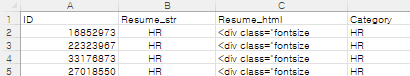

In [5]:
df.Category.unique()

array(['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE',
       'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT',
       'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION'],
      dtype=object)

In [7]:
df = df.loc[df.Category.isin(['CHEF', 'FITNESS'])].reset_index(drop=True)
df.shape

(235, 4)

CHEF, FITNESS와 관련된 이력서만 가져오겠음

In [8]:
print(df.loc[10, 'Resume_str'])

         GROUP FITNESS INSTRUCTOR       Summary    7+ years customer service experience Advanced written and spoken communication skills in varying audiences 2+ years experience working with employers and job seekers in all aspects of job searches 2+ years experience conducting group and individual interviews, anticipating job-readiness, administering aptitude tests and identifying training needs Knowledge of employment and training, state and federal laws, policies, rules and regulations Highly self-motivated with effective time and workload management skills Knowledgeable and intuitive computer hardware and software abilities              Devised a successful recruiting plan for new call centers, which resulted in  [Number]  new employees in  [Number] -months.            Education     2012     Western New Mexico University   City  ,   State       Masters of Business Administration (MBA)             2003     Western Washington University   City  ,   State       Bachelor of Arts  :   E

### 정보 추출하기 step 1 : 필요한 정보 명확히 정의하기
- 우리가 원하는 후보자를 search하기 위해 필요한 정보
- 모든 이력서에 공통적으로 확보할 수 있는 정보

### 정보 추출하기 step 2 : 필요한 정보 추출을 위한 방법 구상하기
- chat completion을 활용할 수 있기 때문에, 생각의 틀을 넓혀서 추출을 위한 최적의 방법을 생각
- chat completion 이외에도 regex나 NER 등 다양한 방법을 활용해도 됨
    - NER, regex를 사용하기에는 자유도가 떨어진다고 생각을 해서, 흔히 이야기하는 chatgpt를 활용할 것임
    - chatgpt 뒤에는 chat completion api가 있는데, 이것을 활용하면 창의적으로 다양한 task를 할당할 수 있음

In [9]:
prompt = """Given the following resume text, 
extract and categorize the information into the specified categories: skills, work experience in years, and summary of each project. 
Please provide the extracted information in a dictionary format with the keys as 'skills', 'work experience (years)' and 'summary.

Instructions:

    Skills: Identify and list all professional skills mentioned in the resume. Each element should be a word such as 'Python' or 'CSS'
    Work Experience (years): Total years of experience. It should be a number such as '7' or '10'. Leave it empty if there are no related information.
    Summary : For each career should be one summarized in one sentence. 
              Each sentence should be in a format of 'Worked as <job_title> from <start_date> to <end_date>, doing <work description> and accomplishing <accomplishments>'.
              Put in 'empty' for each blank if there are on relevant information.
    
Ensure that the information is accurately extracted and categorized according to the instructions. If certain information is not available or cannot be accurately determined, please indicate so appropriately.

Resume Text:
{}
"""

- 위 프롬프트를 제공해서, output을 받을 수 있는 함수가 밑에 정의가 되어 있음

- chat_completion안에 input_prompt를 제공해주면,
    - 위에 prompt에 instruction과 resume text를 제공해주면
    - chat completion 모델 뒷단에 api가 돌면서, 우리가 원하는 결과값을 제공해줌

- json_object로 결과값을 제공해주기 때문에, 이 결과값을 곧 바로 input으로 활용할 수 있음

- async는 여러 api를 동시에 받아서, 동시 다발적으로 받을 수 있음
    - 하나하나 보내는 것보다 더 빠르게 결과값을 받을 수 있음

In [10]:
async def chat_completion(input_prompt, model='gpt-4o'):
    client = AsyncOpenAI()
    
    SYSTEM_PROMPT = "You are a smart and intelligent program that understands information inside a resume, designed to output JSON"
    USER_PROMPT_1 = """Are you clear about your role?"""
    ASSISTANT_PROMPT_1 = """Sure, I'm ready to help you with your NER task. Please provide me with the necessary information to get started."""

    response = await client.chat.completions.create(
        model=model,
        response_format={ "type": "json_object" },
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": USER_PROMPT_1},
            {"role": "assistant", "content": ASSISTANT_PROMPT_1},
            {"role": "user", "content":input_prompt}
        ]
        )
    return response

async def run_async(main_prompt, information):
    tasks = [chat_completion(main_prompt.format(i)) for i in information]
    responses = await asyncio.gather(*tasks)
    return responses

def normal_chat_completion(input_prompt, model='gpt-4o'):
    client = openai.OpenAI()

    response = client.chat.completions.create(
        model=model,
        response_format={ "type": "json_object" },
        messages=[
            {"role": "system", "content": 'You are a smart and intelligent program that understands information and provides output in JSON format'},
            {"role": "user", "content":input_prompt}
        ]
        )
    return response

In [86]:
df_new = pd.read_csv(r"./Resume.csv")
df_new.Resume_str[0:5]

0             HR ADMINISTRATOR/MARKETING ASSOCIATE\...
1             HR SPECIALIST, US HR OPERATIONS      ...
2             HR DIRECTOR       Summary      Over 2...
3             HR SPECIALIST       Summary    Dedica...
4             HR MANAGER         Skill Highlights  ...
Name: Resume_str, dtype: object

In [87]:
df_new.Resume_str[0:5].values

array(["         HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, 

In [88]:
df_new.Resume_str[0:5].values.tolist()

["         HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss p

async (13분 이내)
- with async : 15개당 40~50초
- without async : 15개당 ~180초 (1개당 ~12초)

In [ ]:
batches = (df.Resume_str[i:i+5].values.tolist() for i in range(0, len(df.Resume_str), 5))
outputs = list()

for batch in tqdm(batches):
    try:
        output = await run_async(prompt, batch)
        outputs.extend(output)
    except openai.RateLimitError:
        print("Rate limit hit, waiting 2 seconds...")
        await asyncio.sleep(2)

4it [00:34,  9.42s/it]

Rate limit hit, waiting 2 seconds...


5it [00:43,  9.33s/it]

Rate limit hit, waiting 2 seconds...


7it [01:03,  9.81s/it]

...

Rate limit hit, waiting 2 seconds...


38it [05:57,  8.74s/it]

Rate limit hit, waiting 2 seconds...


39it [06:14,  9.61s/it]


CancelledError: 

In [23]:
len(outputs)

40

In [24]:
outputs[0]

ChatCompletion(id='chatcmpl-Bt3OLNKRXaG9elRy4nerZGlWkwqft', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n  "skills": [\n    "CPR",\n    "AED",\n    "CPI",\n    "wellness advice",\n    "marketing",\n    "teaching",\n    "coaching",\n    "football",\n    "basketball",\n    "baseball",\n    "track & field"\n  ],\n  "work experience (years)": 8,\n  "summary": [\n    "Worked as Fitness Consultant from 09/2013 to 03/2014, conducting tours and giving wellness advice to help every person change their lives, and accomplishing increased business through outside marketing and calls to prospective members.",\n    "Worked as DAEP/Special Education/Coach from 08/2012 to 05/2013, teaching in the DAEP and Special Education wings with Autism and Down Syndrome children, and accomplishing coaching in Football, Basketball, and Strength and Conditioning programs for middle school and high school athletes.",\n    "Worked as PE/Special Education/Coac

worked as 로 전부 나오는데, 이런식으로 나오게 프롬프트를 작성했음
- 문장형태를 고정시켜서 summary를 만든 이유는, 문장 형태가 유사해야 나중에 임베딩 유사도를 계산할 때, 다른 문장구조가 주는 영향을 제거할 수 있음
- 요인들 위주로 코사인 유사도를 구하고 싶은 것임

In [20]:
extracted_info = [i.choices[0].message.content for i in outputs]
extracted_info = [json.loads(i) for i in extracted_info]

In [21]:
extracted_info[0]

{'skills': ['CPR',
  'AED',
  'CPI',
  'wellness advice',
  'marketing',
  'teaching',
  'coaching',
  'football',
  'basketball',
  'baseball',
  'track & field'],
 'work experience (years)': 8,
 'summary': ['Worked as Fitness Consultant from 09/2013 to 03/2014, conducting tours and giving wellness advice to help every person change their lives, and accomplishing increased business through outside marketing and calls to prospective members.',
  'Worked as DAEP/Special Education/Coach from 08/2012 to 05/2013, teaching in the DAEP and Special Education wings with Autism and Down Syndrome children, and accomplishing coaching in Football, Basketball, and Strength and Conditioning programs for middle school and high school athletes.',
  'Worked as PE/Special Education/Coach from 08/2009 to 05/2012, teaching PE classes and Content Mastery programs, and accomplishing coaching in Football, Basketball, Baseball, and Track & Field through various teams and levels.',
  'Worked as Sales from 07/2

In [22]:
# for i, info in enumerate(extracted_info):
#     extracted_info[i]['ID'] = str(df.loc[i, 'ID'])
#     extracted_info[i]['title'] = df.loc[i, 'title']
    
# with open(r".\resume\resume_info_extracted.json", 'w') as file:
#     json.dump(extracted_info, file)

40

In [26]:
with open(r".\resume\resume_info_extracted.json", 'r') as file:
    data = json.load(file)

In [27]:
data[0]

{'skills': ['CPR/AED Certified', 'CPI Certified', 'THSCA Member'],
 'work experience (years)': '7',
 'summary': ['Worked as Fitness Consultant from 09/2013 to 03/2014, doing tours, wellness advice, outside marketing, and calls to prospective members.',
  'Worked as DAEP/Special Education/Coach from 08/2012 to 05/2013, doing teaching in DAEP, working with Autism and Down Syndrome children in Special Education, and coaching Football, Basketball, and Strength and Conditioning programs.',
  'Worked as PE/Special Education/Coach from 08/2009 to 05/2012, doing teaching in Middle School PE and Content Mastery programs, working with Special Education at various levels, and coaching Football, Basketball, Baseball, and Track & Field.',
  'Worked as Sales from 07/2014 to Current, doing business growth, maintaining detailed records of jobs and potential clients, and maintaining client relations.'],
 'ID': '17576030',
 'title': 'FITNESS CONSULTANT'}

In [30]:
k, v = data[0].items()
print(f"k: {k}")
print(f"v: {v}")

ValueError: too many values to unpack (expected 2)

## <font color=yellow>2. 추출한 데이터를 임베딩 시켜줌 </font>

In [28]:
from utils import create_embeddings

In [31]:
emb_data = list()

for d in tqdm(data):
    emb_d = dict()
    for k, v in d.items():
        if k in ['skills', 'summary', 'title']:
            emb_ = create_embeddings(v) # list를 한 번에 embedding화
            emb_d[k] = emb_
        elif k in ['work experience (years)', 'ID']:
            emb_d[k] = v
        else:
            assert False, "Incorrect key"
    emb_data.append(emb_d)

  0%|          | 1/235 [00:05<20:23,  5.23s/it]


KeyboardInterrupt: 

In [ ]:
# with open(r".\resume\resume_info_extracted_emb.json", 'w') as file:
#     json.dump(emb_data, file)

In [32]:
with open(r".\resume\resume_info_extracted_emb.json", 'r') as file:
    emb_data = json.load(file)

In [33]:
emb_data[0].keys()

dict_keys(['skills', 'work experience (years)', 'summary', 'ID', 'title'])

In [ ]:
emb_data[0]

## <font color=yellow>3. Search </font>
- skill
    - threshold를 정해서, 가장 유사하다고 판단이 되는 것을 가져온다. 유사도의 평균 또는 몇 개 일치하는지
- summary of project
    - 어떤 프로젝트를 했는지, description을 기준으로

In [36]:
input_dict = {'skills':['Flexibility Training', 'Nutrition', 'Anatomy', 'Strength Training'],
              'summary':"Extensive experience in designing and implementing personalized training programs for muscle growth, with a proven track record of helping clients achieve their fitness goals"}

In [37]:
df = pd.DataFrame(data)
emb_df = pd.DataFrame(emb_data)

In [38]:
df.head(3)

,skills,work experience (years),summary,ID,title
0,"[CPR/AED Certified, CPI Certified, THSCA Member]",7,[Worked as Fitness Consultant from 09/2013 to ...,17576030,FITNESS CONSULTANT
1,"[Fitness assessments, Body Mass Index (BMI) kn...",11,[Worked as Fitness Specialist from Aug 2015 to...,24444525,FITNESS SPECIALIST
2,"[Genetic nutrition, Adult nutrition, Adolescen...",3,[Worked as Fitness Attendant from March 2014 t...,10268614,FITNESS ATTENDANT


In [39]:
emb_df.head(3)

,skills,work experience (years),summary,ID,title
0,"[[-0.02385825291275978, -0.003918746951967478,...",7,"[[-0.04736968129873276, 0.005048827733844519, ...",17576030,"[[-0.01816573739051819, 0.028289277106523514, ..."
1,"[[-0.009631882421672344, 0.0322096049785614, 0...",11,"[[-0.0477861724793911, 0.023125329986214638, 0...",24444525,"[[-0.02081730030477047, 0.049040619283914566, ..."
2,"[[-0.015874864533543587, 0.039554428309202194,...",3,"[[-0.03412704914808273, 0.025285640731453896, ...",10268614,"[[-0.022732090204954147, 0.06460243463516235, ..."


In [47]:
def batch_cosine_similarity(list1, list2, threshold):
    # sklearn의 cosine_similarity 함수를 사용하여 코사인 유사도 계산
    similarities = cosine_similarity(list1, list2)
    columns_over_threshold = (similarities > threshold).any(axis=0)
    
    count = columns_over_threshold.sum() # list2를 기준으로 한 개라도 threshold를 넘는 값이 있으면 +1
    column_indices = np.where(columns_over_threshold)[0]

    return column_indices, count

def candidate_search(input_list, nested_lists, top_k, search_type='skill', threshold=0.5):
    """
    score : 0-1 사이의 값. 높을 수록 더 많은 match. Match의 max는 nested_list의 개수와 동일
    현재 input으로 제공된 embedding 값과, nested_lists에 있는 element들의 embedding 값들의 cosine similarity를 계산
    """
    if search_type in ['experience', 'skill']:
        pass
    else:
        assert False, "Unsupported search type"

    scores = list()
    
    for i, nested_list in enumerate(nested_lists):
        # input_list와 nested_lists를 대상으로 cosine similarity를 계산, 각 element 별로 cos_sim이 threshold를 넘는 값들만 가져옴
        _, common_elements_count = batch_cosine_similarity(input_list, nested_list, threshold)
        # print(common_elements_count)
        # 정규화를 위해 nested_list의 길이 계산
        possible_matches = len(nested_list)
        # 점수 계산 (common_elements_count / possible_matches)
        score = common_elements_count / possible_matches if possible_matches > 0 else 0
        scores.append((i, score))
    
    top_scores = sorted(scores, key=lambda x: x[1], reverse=True)[:top_k]

    return top_scores

### <font color=yellow>===예시===</font>

In [40]:
# db = emb_df['skills'].values.tolist()
input_emb = create_embeddings(input_dict['skills'])
input_dict['skills']

['Flexibility Training', 'Nutrition', 'Anatomy', 'Strength Training']

In [41]:
candidate_skills = ['Nutritions', 'Training', 'Calisthenics']
candidate_emb = create_embeddings(candidate_skills)

In [42]:
cos = cosine_similarity(input_emb, candidate_emb)
cos

array([[0.24080119, 0.45700053, 0.39079476],
       [0.80069463, 0.27836959, 0.24456574],
       [0.30003518, 0.28421833, 0.24000874],
       [0.29780098, 0.43935138, 0.49591301]])

(similarities > threshold).any(axis=0)
- column으로 계산했을 때, 이 후보자가 threshold가 넘는게 하나라도 있을때
- 즉, 우리가 원하는 스킬을 몇 개 가지고 있는지

In [43]:
columns_over_threshold = (cos > 0.4).any(axis=0)
columns_over_threshold

array([ True,  True,  True])

스킬 위주로 유사도를 한 번 훑은 다음,
- 경험을 가지고 스캔하는 투 트랙으로 감

### <font color=yellow>3-1. skill based search</font>

In [55]:
db = emb_df['skills'].values.tolist()
input = create_embeddings(input_dict['skills'])

In [56]:
input_dict['skills']

['Flexibility Training', 'Nutrition', 'Anatomy', 'Strength Training']

In [57]:
skill_based_findings = candidate_search(input, db, 10, threshold=0.5)
skill_based_findings

[(2, np.float64(0.3333333333333333)),
 (1, np.float64(0.2857142857142857)),
 (57, np.float64(0.1875)),
 (37, np.float64(0.15384615384615385)),
 (43, np.float64(0.15151515151515152)),
 (35, np.float64(0.125)),
 (70, np.float64(0.125)),
 (4, np.float64(0.11764705882352941)),
 (53, np.float64(0.10810810810810811)),
 (22, np.float64(0.10714285714285714))]

In [61]:
len(db[1])

14

In [62]:
df.loc[1, 'skills']

['Fitness assessments',
 'Body Mass Index (BMI) knowledge',
 'Understanding of body fat tables and BMI',
 'Fitness equipment operation',
 'Weight management expert',
 'CPR and First Aid certified',
 'Understanding of human anatomy',
 'Gymnast',
 'AED certification',
 'Fitness equipment expertise',
 'Fitness programming specialist',
 'Computer literate',
 'Educator',
 'Bilingual']

In [63]:
idx, counts = batch_cosine_similarity(input, db[1], 0.5)
idx

array([ 3,  6,  9, 10])

In [64]:
df.loc[1, 'skills'][10]

'Fitness programming specialist'

### <font color=yellow>3-2. summary based search</font>

In [65]:
summary_db = emb_df['summary'].values.tolist()
input_summary = create_embeddings(input_dict['summary'])

In [66]:
input_dict['summary']

'Extensive experience in designing and implementing personalized training programs for muscle growth, with a proven track record of helping clients achieve their fitness goals'

In [67]:
summary_based_findings = candidate_search(input_summary, summary_db, 10, 'experience')
summary_based_findings

[(29, np.float64(1.0)),
 (34, np.float64(1.0)),
 (27, np.float64(0.75)),
 (66, np.float64(0.6666666666666666)),
 (22, np.float64(0.6)),
 (43, np.float64(0.5)),
 (20, np.float64(0.4)),
 (46, np.float64(0.4)),
 (57, np.float64(0.4)),
 (6, np.float64(0.3333333333333333))]

In [68]:
df.loc[29, 'summary']

['Worked as Personal Trainer from Jun 2010 to Current, doing training, coaching, and mentoring with a focus on health and fitness, and accomplishing significant client-base growth through social media, exceptional customer service for 15,000+ members, and leadership of a 20 person team.',
 'Worked as Fitness Manager from Mar 2015 to Mar 2015, doing tracking sales, developing training programs, managing 16 personal trainers, and overseeing all operations on the floor/group training.']

In [69]:
df.loc[34, 'summary']

['Worked as Certified Master Personal Trainer from 06/2013 to Current, doing personal training to improve overall function, endurance, strength, flexibility, and balance, and accomplishing detailed record-keeping and program customization to meet individual needs.',
 'Worked as Fitness Director - Certified Personal Trainer from 06/2008 to 06/2013, doing client fitness evaluations, trainer schedule management, and sales training, and accomplishing personal training package sales and a client retention rate of 80%.',
 'Worked as Fitness Director - Certified Personal Trainer from 01/2007 to 06/2008, doing fitness staff management and training in sales and exercise techniques, and accomplishing successful sales of personal training packages.']

skillset보다 경험에 가중치를 더 준, 가중 평균으로 계산할 할 것 같음
- 후보군 id 선별

## <font color=yellow>4. Service</font>
- 여기서 service로 가기에는 10%가 약간 모자름
- 10%를 채우기 위해서는, input을 어떻게 받아들일까를 고민

#### 1. 정형화된 input field
```python
input_dict = {'skills':['Flexibility Training', 'Nutrition', 'Anatomy', 'Strength Training'],
              'summary':"Extensive experience in designing and implementing personalized training programs for muscle growth, with a proven track record of helping clients achieve their fitness goals"}
```

#### 2. 비정형 input field (free text)
```python
???
```
    - step 1 : Input을 분석하여 search를 trigger하는 layer
    - step 2 : 요구사항을 분석하여 필요한 skill과 경험을 생성해주는 layer
    - step 3 : search

### <font color=red>Step 1 : trigger layer 생성</font>

In [70]:
job_req = "I want to grow muscle mass considering nutrient intake as well as various muscle training drills."

- 예상할 수 있는 질문들을 미리 적어놓음

In [71]:
job_search_queries = ["Improving physical fitness through a combination of general physical education activities, balanced exercise routines, and nutritional awareness.",
                      "Enhancing overall health with a mix of diverse physical education exercises, targeted workouts, and mindful eating habits.",
                      "Increasing muscle volume by integrating nutritional strategies with multifaceted workout routines.",
                      "Building muscle density by focusing on nutrient-rich diets and comprehensive resistance training programs.",
                      "Streamlining trainer scheduling and client management to optimize the efficiency and effectiveness of a fitness facility.",
                      "Implementing cutting-edge fitness technology and equipment maintenance protocols to ensure a state-of-the-art workout environment.",
                      "Developing comprehensive staff training programs to elevate the expertise and service quality of personal trainers and fitness instructors.",
                      "Enforcing health and safety standards to provide a secure and hygienic environment for members and staff alike.",
                      "Cultivating a community-focused atmosphere through member engagement initiatives and personalized fitness guidance to enhance client retention and satisfaction."]

In [77]:
job_search_query_embs = create_embeddings(job_search_queries)
input_emb = create_embeddings(job_req)

In [78]:
def route_selection(query_emb, emb_list, threshold=0.5):
    cos_sim = cosine_similarity(query_emb, emb_list)
    threshold_check = cos_sim > threshold

    if threshold_check.sum() > 0:
        return True
    else:
        return False

In [79]:
route_selection(input_emb, job_search_query_embs)

True

False가 나오면, 우리가 미리 지정해놓은 scope안에 들어오지 않는 요구사항이기 때문에, 현재 우리 서비스에서 제공할 수 없다고 말함

### <font color=red>Step 2 : 요구 사항을 분석하여 skill과 경력을 생성하는 layer (input dataset 생성)</font>

In [80]:
prompt = """
Analyze the provided task description to identify and categorize the essential qualifications and expertise required for the job. 
The analysis should focus on extracting relevant skills and summarizing the job capabilities necessary for achieving the specified goal.
Organize this information into a structured dictionary format.

Categories: Skills and Summary.

Instructions:
- Skills: Enumerate the critical skills necessary for someone to effectively fulfill the job requirements. These should be simple words such as 'Anatomy' or 'Strength Training'
- Summary: Draft a concise job description that encapsulates the professional experience and competencies needed to successfully execute the job responsibilities. 
            One example would be : "Extensive experience in designing and implementing personalized training programs for muscle growth, with a proven track record of helping clients achieve their fitness goals"

Please provide the extracted information in a dictionary format with the keys as 'skills' and 'summary'.

Task description:
{}
"""

요구사항을 분석해서, 이전에 만든 input 딕셔너리처럼 skill과 경력 set를 만들어야함
- 실제 프로젝트 였으면 다른 문서를 참고해서 가져올 수도 있음

In [81]:
output = normal_chat_completion(prompt.format(job_req))

In [82]:
json.loads(output.choices[0].message.content)

{'skills': ['Nutrition',
  'Muscle Training',
  'Strength Training',
  'Personalized Program Design'],
 'summary': 'Proficient in developing comprehensive muscle gain programs that incorporate nutrient intake analysis and targeted muscle training drills. Demonstrated ability to tailor fitness regimens to individual needs ensuring efficient and effective muscle growth for clients.'}

### <font color=red>Step 3 : 위에서 진행한 Search</font>